In [1]:
import os

# Path setup: works locally; for Colab, set USE_COLAB=True and run drive mount first
BASE_DIR = os.getcwd()
USE_COLAB = False

if USE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/Project 005 Data'
    os.chdir(BASE_DIR)

# Deseason files + moving average (AVG) file
DESEASON_FILES = [
    ("Transformed_Deseason_Residuals.xlsx", "Residuals (FFT/ACF)"),
    ("Transformed_Deseason_Diff1.xlsx", "Diff1 (First-Difference)"),
    ("Master_Data_AVG_version_update.xlsx", "AVG (Moving Average)"),
]
# Fallback if files not in cwd
for fname, _ in DESEASON_FILES:
    p = os.path.join(BASE_DIR, fname)
    if not os.path.exists(p):
        for d in [os.path.expanduser("~/Downloads/Project 005 Data"), os.path.dirname(os.path.abspath("."))]:
            if os.path.exists(os.path.join(d, fname)):
                BASE_DIR = d
                break
    break

print(f"BASE_DIR: {BASE_DIR}")

BASE_DIR: /Users/andyyang/Downloads/Project 005 Data


In [2]:
# Upgrade statsmodels + scipy (fixes SciPy deprecate_kwarg mismatch). Pure Python — works in any kernel.
import subprocess
import sys

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-U",
        "statsmodels>=0.14.4",
        "scipy",
    ]
)

0

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
# Load both deseason files
# Exclude model-generated variables (e.g. XGBoost predictions) to avoid feature leakage
MODEL_GENERATED_PATTERNS = ["XGBoost_pred", "_pred"]  # extend as needed for other model outputs

features_dict = {}
# Stem of the workbook actually read per label (used in Lagged output names: *_Lagged__from_<stem>.xlsx)
FEATURE_INPUT_STEM_BY_LABEL = {}
for fname, label in DESEASON_FILES:
    path = os.path.join(BASE_DIR, fname)
    if os.path.exists(path):
        df = pd.read_excel(path)
        date_col = "Date" if "Date" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        # Drop model-generated columns before adding to features
        exclude_cols = [c for c in df.columns if any(p in str(c) for p in MODEL_GENERATED_PATTERNS)]
        if exclude_cols:
            df = df.drop(columns=exclude_cols)
            print(f"Excluded model-generated cols from {fname}: {exclude_cols}")
        features_dict[label] = df
        FEATURE_INPUT_STEM_BY_LABEL[label] = Path(path).stem
        print(f"Loaded {fname}: {df.shape[0]} rows, {df.shape[1]} cols")
    else:
        print(f"Warning: {path} not found")

Loaded Transformed_Deseason_Residuals.xlsx: 3424 rows, 177 cols
Loaded Transformed_Deseason_Diff1.xlsx: 3424 rows, 178 cols
Excluded model-generated cols from Master_Data_AVG_version_update.xlsx: ['log_C5_XGBoost_pred_x', 'log_C5_XGBoost_pred_y', 'log_C5_XGBoost_pred', 'C5_XGBoost_pred']
Loaded Master_Data_AVG_version_update.xlsx: 5265 rows, 180 cols


In [5]:
# Use first loaded file for backward compatibility (PACF example cells)
features = list(features_dict.values())[0] if features_dict else None

In [6]:
# Optional: load target (c5) from Master Data (Brownian-by-frequency preferred)
_master_candidates = [
    "Master_Data_Base_version_Brownian_by_frequency.xlsx",
    "Master_Data_AVG_version_update.xlsx",
]
master_path = None
for _fname in _master_candidates:
    _p = os.path.join(BASE_DIR, _fname)
    if os.path.exists(_p):
        master_path = _p
        break
if master_path:
    print(f"Using master: {master_path}")
    c5 = pd.read_excel(master_path).iloc[:, 0:2]
    date_col = "Date" if "Date" in c5.columns else c5.columns[0]
    c5[date_col] = pd.to_datetime(c5[date_col])
    c5.set_index(date_col, inplace=True)
else:
    raise FileNotFoundError(
        "No master workbook found. Tried: " + ", ".join(_master_candidates)
    )


Using master: /Users/andyyang/Downloads/Project 005 Data/Master_Data_Base_version_Brownian_by_frequency.xlsx


In [7]:
# Through 2026 so CCF / targets align with extended master (forecast horizons).
c5 = c5.loc[(c5.index >= "2013-01-01") & (c5.index <= "2026-12-31")]


In [8]:
import numpy as np
# Level C5 target for alignment / CCF (not log-transformed)
c5_numeric = c5.select_dtypes(include=[np.number])
if "C5" in c5_numeric.columns:
    target_c5 = c5_numeric[["C5"]].copy()
else:
    target_c5 = c5_numeric.iloc[:, :1].copy()
target_c5.index = pd.to_datetime(target_c5.index)


PACF

In [9]:
x = features.iloc[:,1]

In [10]:
x_non_0 = x.loc[x != 0]

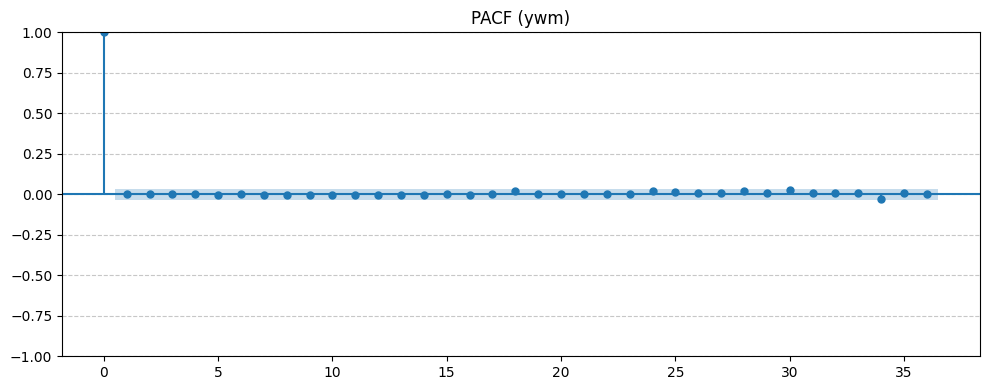

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(
    x_non_0.dropna(),
    lags=36,
    method="ywm",
    alpha=0.05,
    ax=ax,
)
ax.set_title("PACF (ywm)")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Test run PACF

In [12]:
from statsmodels.tsa.stattools import pacf

N = len(x_non_0)
max_lags = 36
significant_lags = []
stop_counter = 0

pacf_scores = pacf(x_non_0.dropna(), nlags = 36, method = "ywm")

threshold = 1.96 / np.sqrt(N)

for lag in range(1, max_lags + 1):
        score = pacf_scores[lag]
        if abs(score) > threshold:
          significant_lags.append(lag)
          stop_counter = 0
        else:
          stop_counter += 1
        if stop_counter == 3:
          break




In [13]:
significant_lags

[]

PACF: Optimal lag for each variable (both deseason files)

Optimal lag = argmax(|PACF|), shown for every variable regardless of threshold/significance.

In [14]:
features.columns

Index(['China Manufacturing Purchasing Managers Index (Official)_PMI_season143d_ar21',
       'Industrial Production  China_% Yr/Yr_season190d_ar24',
       'Industrial Production  Japan_% Yr/Yr_season171d_ar23',
       'Industrial Production  S Korea_% Yr/Yr_season180d_ar24',
       'China Steel Production_,000 tonnes_season63d_ar24',
       'Japan Steel Production_,000 tonnes_season63d_ar24',
       'South Korea Steel Production_,000 tonnes_season63d_ar24',
       'P.R. China BFI Production_,000 tonnes_season63d_ar24',
       'Japan BFI Production_,000 tonnes_season211d_ar1',
       'R.O.Korea BFI Production_,000 tonnes_season211d_ar22',
       ...
       'steel margin cash profit with cost delayed 1 month for marginal producer of Rebar_season133d_ar1',
       'steel margin cash profit with cost delayed 1 week for marginal producer of Rebar_season144d_ar1',
       'steel margin cash profit with cost delayed 1 month for marginal producer of HRC_season115d_ar1',
       'steel margin ca

In [15]:
# Grouping lists come from the Excel classification cell below (monthly_data / weekly_data / daily_data).
# Do not overwrite them here.
pass


In [16]:
# monthly_data / weekly_data / daily_data are set in the Excel classification grouping cell.
pass


In [17]:
from statsmodels.tsa.stattools import pacf

# Optimal lag = argmax(|PACF|) for each variable, regardless of threshold/significance
# Run on BOTH deseason files (run Transform & Deseason first to generate them)
optimal_lag_by_file = {}

if not features_dict:
    print("No deseason files loaded. Run Transform & Deseason notebook first.")

for label, features_df in features_dict.items():
    columns_to_process = list(features_df.columns)  # Process ALL columns
    optimal_lag = {}

    for column in columns_to_process:
        x = features_df[column].dropna()
        x_non_0 = x.loc[x != 0]
        N = len(x_non_0)

        if N < 15:
            optimal_lag[column] = None
            continue

        max_lags = min(36, (N // 2) - 1)
        if max_lags < 1:
            optimal_lag[column] = None
            continue

        pacf_scores = pacf(x_non_0, nlags=max_lags, method="ywm")
        # Optimal lag = lag with maximum |PACF| (excluding lag 0)
        abs_pacf = np.abs(pacf_scores[1 : max_lags + 1])
        best_idx = np.argmax(abs_pacf)
        optimal_lag[column] = int(best_idx + 1)

    optimal_lag_by_file[label] = optimal_lag

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


In [18]:
import pandas as pd

# Feature groups from Column_Frequency_Classification.xlsx (Detailed_Classification sheet)
CLASSIFICATION_XLSX = os.path.join(BASE_DIR, "Column_Frequency_Classification.xlsx")
DETAILED_SHEET = "Detailed_Classification"


def _freq_bucket_from_label(s):
    t = str(s).strip().lower()
    if "daily" in t or "frequent" in t:
        return "daily"
    if "week" in t:
        return "weekly"
    if "month" in t or "quarter" in t or "year" in t or "rare" in t:
        return "monthly"
    return "daily"


_cls = pd.read_excel(CLASSIFICATION_XLSX, sheet_name=DETAILED_SHEET)
_need = {"Column_Name", "Frequency_Classification"}
if not _need.issubset(set(_cls.columns)):
    raise ValueError(f"{DETAILED_SHEET} must contain columns {_need}")
_cls = _cls.drop_duplicates(subset=["Column_Name"], keep="last")
RAW_NAME_TO_BUCKET = {
    row["Column_Name"]: _freq_bucket_from_label(row["Frequency_Classification"])
    for _, row in _cls.iterrows()
}


def _bucket_for_engineered_column(col):
    if col in RAW_NAME_TO_BUCKET:
        return RAW_NAME_TO_BUCKET[col]
    if "_season" in col:
        base = col.split("_season")[0]
        if base in RAW_NAME_TO_BUCKET:
            return RAW_NAME_TO_BUCKET[base]
    for k in sorted(RAW_NAME_TO_BUCKET.keys(), key=len, reverse=True):
        if col.startswith(k):
            return RAW_NAME_TO_BUCKET[k]
    return "daily"


monthly_data = []
weekly_data = []
daily_data = []

for col in features.columns:
    b = _bucket_for_engineered_column(col)
    if b == "monthly":
        monthly_data.append(col)
    elif b == "weekly":
        weekly_data.append(col)
    else:
        daily_data.append(col)

print(f"monthly_data (Excel classification): {len(monthly_data)} cols")
print(f"weekly_data (Excel classification): {len(weekly_data)} cols")
print(f"daily_data (Excel classification): {len(daily_data)} cols")

monthly_data (Excel classification): 68 cols
weekly_data (Excel classification): 43 cols
daily_data (Excel classification): 66 cols


In [19]:
# Build combined table: Variable | Optimal_Lag_Residuals | Optimal_Lag_Diff1
all_vars = set()
for lag_dict in optimal_lag_by_file.values():
    all_vars.update(lag_dict.keys())
all_vars = sorted(all_vars)

rows = []
for var in all_vars:
    row = {"Variable": var}
    for label, lag_dict in optimal_lag_by_file.items():
        short = label.split()[0]  # "Residuals" or "Diff1"
        row[f"Optimal_Lag_{short}"] = lag_dict.get(var)
    rows.append(row)

optimal_lag_df = pd.DataFrame(rows)

# Add Group column (Excel frequency classification; unlisted vars → other)
def _get_group(var):
    if var in monthly_data: return 'monthly'
    if var in weekly_data: return 'weekly'
    if var in daily_data: return 'daily'
    return 'other'
optimal_lag_df['Group'] = optimal_lag_df['Variable'].map(_get_group)
optimal_lag_df

,Variable,Optimal_Lag_Residuals,Optimal_Lag_Diff1,Optimal_Lag_AVG,Group
0,EAF Margin 1 week scrap inventory(RHS),NaN,1.0,1.0,other
1,EAF Margin 1 week scrap inventory(RHS)_season...,31.0,NaN,NaN,daily
2,1 Month FFA Route Average,NaN,1.0,1.0,other
3,1 Month FFA Route Average_season245d_ar20,22.0,NaN,NaN,daily
4,2 Month FFA Route Average,NaN,1.0,1.0,other
...,...,...,...,...,...
352,trader inv consumption Medium plate_season132d...,30.0,NaN,NaN,weekly
353,trader inv consumption Rebar,NaN,1.0,1.0,other
354,trader inv consumption Rebar_season132d_ar36,33.0,NaN,NaN,weekly
355,trader inv consumption Wire rod,NaN,1.0,1.0,other


### CCF-based Lag/MA for Lagged Output

Uses **cross-correlation with target** (level **C5**) to select optimal lag and rolling-window size for each feature, instead of PACF. For each column:
- **Lag**: search `shift(1), ..., shift(k)` up to **63 business days** (`MAX_CCF_LAG`, also capped by half the aligned series length) and pick `k` that maximizes |corr(shifted, target)|
- **MA**: `rolling(1).mean(), ..., rolling(k).mean()` over the same `k` range and pick the window that maximizes |corr(rolling, target)|

The exported Lagged workbooks are named **`{prefix}_Lagged__from_{input_stem}.xlsx`**, where **`input_stem`** is the stem of the Excel file actually loaded for that channel (see **`FEATURE_INPUT_STEM_BY_LABEL`**). Residuals / Diff1 use their file stem as `prefix`; the moving-average channel uses prefix **`Moving_Average_Features`**. **`Optimal_Lag_Summary__from_{master_stem}.xlsx`** tags the C5 master used for alignment when **`master_path`** is set. Each file includes **two columns per feature**: CCF-optimal **lag** (`_lag_<k>`) and **MA** (`_ma_<w>`). The index is extended by **at least max(lag)** and **max(MA window)** business days after the last source date, and through **`LAGGED_INDEX_END`** (default **2026-12-31**) when that reaches further into **2025–2026**; raw features are **forward-filled** on new dates before lag/MA. Each `_lag_k` column blanks from row `n_orig + k` onward; **`_ma_*` values are carried through the extended index** (last in-sample MA forward-filled on 2025/2026 rows where needed). The summary still has `CCF_Selected_*`.



In [20]:
# CCF-based optimal lag and MA for lagged output (correlation with target)
# Replaces PACF for building Transformed_Deseason_*_Lagged.xlsx
LAGGED_LABELS = ["Residuals (FFT/ACF)", "Diff1 (First-Difference)", "AVG (Moving Average)"]
N_FEATURES_CCF = 180
# CCF lag/MA search cap (business days). Kept at 63 (~3 months) to match Phase-2 daily PACF/CCF caps
# and avoid very long windows dominating |corr|; change only if you intentionally want a wider grid.
MAX_CCF_LAG = 63

# Target: level C5 from master
df_target = target_c5.copy()
target_col = df_target.columns[0] if isinstance(df_target, pd.DataFrame) else df_target.name
if isinstance(df_target, pd.DataFrame):
    y_series = df_target[target_col].copy()
else:
    y_series = df_target.copy()
y_series.index = pd.to_datetime(y_series.index)

ccf_optimal_by_file = {}

for label in LAGGED_LABELS:
    if label not in features_dict:
        continue
    features_df = features_dict[label].copy()
    features_df.index = pd.to_datetime(features_df.index)
    numeric_cols = list(features_df.select_dtypes(include=[np.number]).columns)[:N_FEATURES_CCF]

    common_idx = features_df.index.intersection(y_series.index)
    X_aligned = features_df.loc[common_idx].copy()
    y_aligned = y_series.loc[common_idx].dropna()
    align_df = X_aligned.copy()
    align_df["_target"] = y_aligned
    align_df = align_df.dropna(subset=["_target"])

    ccf_optimal_by_file[label] = {}
    print(f"CCF for {label}: {len(numeric_cols)} columns, {len(align_df)} aligned rows")

    def _ccf_default():
        return {
            "lag": 1,
            "ma": 1,
            "transform": "lag",
            "max_abs_corr_lag": 0.0,
            "max_abs_corr_ma": 0.0,
        }

    for col in numeric_cols:
        if col not in align_df.columns:
            ccf_optimal_by_file[label][col] = _ccf_default()
            continue

        x_clean = align_df[col].replace(0, np.nan).dropna()
        N = len(x_clean)
        if N < 20:
            ccf_optimal_by_file[label][col] = _ccf_default()
            continue

        max_test = min(MAX_CCF_LAG, (N // 2) - 1)
        if max_test < 1:
            ccf_optimal_by_file[label][col] = _ccf_default()
            continue

        best_lag, best_ma = 1, 1
        max_corr_lag, max_corr_ma = 0.0, 0.0

        for k in range(1, max_test + 1):
            shifted = align_df[col].shift(k)
            corr_lag = shifted.corr(align_df["_target"])
            if pd.notna(corr_lag) and abs(corr_lag) > max_corr_lag:
                max_corr_lag = abs(corr_lag)
                best_lag = k

            rolling = align_df[col].rolling(window=k, min_periods=1).mean()
            corr_ma = rolling.corr(align_df["_target"])
            if pd.notna(corr_ma) and abs(corr_ma) > max_corr_ma:
                max_corr_ma = abs(corr_ma)
                best_ma = k

        transform = "lag" if max_corr_lag >= max_corr_ma else "ma"
        ccf_optimal_by_file[label][col] = {
            "lag": best_lag,
            "ma": best_ma,
            "transform": transform,
            "max_abs_corr_lag": max_corr_lag,
            "max_abs_corr_ma": max_corr_ma,
        }

print("CCF optimal lag/MA computed for lagged output.")


CCF for Residuals (FFT/ACF): 177 columns, 3246 aligned rows
CCF for Diff1 (First-Difference): 178 columns, 3246 aligned rows
CCF for AVG (Moving Average): 179 columns, 3246 aligned rows


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CCF optimal lag/MA computed for lagged output.


In [21]:
# Two columns per feature: optimal lag (CCF) and optimal MA (CCF), both exported.
# Names: <base>_lag_<k> and <base>_ma_<w>. Index extends past the last source date by at least
# max(opt_lag) AND max(opt_ma) business days; then through LAGGED_INDEX_END (default 2026-12-31) if later (2025/2026).
# Raw features are forward-filled on new dates, then shift / rolling (causal lags unchanged).
# Each _lag_k column: values blanked from row position n_orig + k onward (same rule as before).
# _ma_* columns: rolling mean, historical NaN->0; extension rows use last in-sample MA so 2025/2026 are populated.
# CCF "selected" in Optimal_Lag_Summary is unchanged.
LAGGED_INDEX_END = pd.Timestamp("2026-12-31")  # None = extend by max(max(lag), max(ma)) bdays only (no calendar cap)

# Third tuple entry: optional output name prefix before _Lagged__from_<input_stem>.xlsx (None => fname stem).
# <input_stem> is the stem of the workbook actually loaded for that label (see FEATURE_INPUT_STEM_BY_LABEL).
LAGGED_OUTPUT_FILES = [
    ("Transformed_Deseason_Residuals.xlsx", "Residuals (FFT/ACF)", None),
    ("Transformed_Deseason_Diff1.xlsx", "Diff1 (First-Difference)", None),
    ("Master_Data_AVG_version_update.xlsx", "AVG (Moving Average)", "Moving_Average_Features"),
]
N_FEATURES = 180

lagged_files = {}
for fname, label, out_prefix in LAGGED_OUTPUT_FILES:
    if label not in features_dict:
        continue
    features_df = features_dict[label].copy().sort_index()
    last_dt = features_df.index.max()
    ccf_dict = ccf_optimal_by_file.get(label, {})
    numeric_cols = list(features_df.select_dtypes(include=[np.number]).columns)[:N_FEATURES]
    opt_lags = [int(ccf_dict.get(c, {"lag": 1}).get("lag", 1)) for c in numeric_cols]
    opt_mas = [int(ccf_dict.get(c, {"lag": 1, "ma": 1}).get("ma", 1)) for c in numeric_cols]
    K = max(opt_lags) if opt_lags else 1
    K_ma = max(opt_mas) if opt_mas else 1
    first_extra = last_dt + pd.offsets.BDay(1)
    end_by_lag = last_dt
    for _ in range(K):
        end_by_lag = end_by_lag + pd.offsets.BDay(1)
    end_by_ma = last_dt
    for _ in range(K_ma):
        end_by_ma = end_by_ma + pd.offsets.BDay(1)
    end_extend = max(end_by_lag, end_by_ma)
    if LAGGED_INDEX_END is not None:
        end_extend = max(end_extend, pd.Timestamp(LAGGED_INDEX_END))
    extra_idx = pd.bdate_range(start=first_extra, end=end_extend)
    extended_index = features_df.index.union(extra_idx).sort_values()
    feat_ext = features_df.reindex(extended_index)
    feat_ext = feat_ext.ffill()
    n_orig = len(features_df)

    cols_list = []
    for col in numeric_cols:
        opt = ccf_dict.get(
            col,
            {"lag": 1, "ma": 1, "transform": "lag"},
        )
        opt_lag = int(opt.get("lag", 1))
        opt_ma = int(opt.get("ma", 1))
        s = feat_ext[col]
        lag_raw = s.shift(opt_lag)
        if len(lag_raw) > n_orig + opt_lag:
            lag_raw.iloc[n_orig + opt_lag :] = float("nan")
        lag_series = lag_raw.copy()
        lag_series.loc[lag_series.index <= last_dt] = lag_series.loc[lag_series.index <= last_dt].fillna(0)
        ma_series = s.rolling(window=opt_ma, min_periods=1).mean()
        hist_ix = ma_series.index <= last_dt
        ma_series.loc[hist_ix] = ma_series.loc[hist_ix].fillna(0)
        ext_ix = ma_series.index > last_dt
        if ext_ix.any():
            h = ma_series.loc[hist_ix]
            anchor = float(h.iloc[-1]) if len(h) and pd.notna(h.iloc[-1]) else np.nan
            if pd.notna(anchor):
                ma_series.loc[ext_ix] = ma_series.loc[ext_ix].fillna(anchor)
            else:
                ma_series.loc[ext_ix] = ma_series.loc[ext_ix].ffill()
        cols_list.append(lag_series.rename(f"{col}_lag_{opt_lag}"))
        cols_list.append(ma_series.rename(f"{col}_ma_{opt_ma}"))

    out_df = pd.concat(cols_list, axis=1)
    lagged_files[label] = out_df

# Save both outputs as separate Excel files (two columns per numeric feature: lag + MA)
for fname, label, out_prefix in LAGGED_OUTPUT_FILES:
    if label not in lagged_files:
        continue
    df = lagged_files[label]
    _inp_stem = FEATURE_INPUT_STEM_BY_LABEL.get(label)
    if not _inp_stem:
        print(f"Skip save for {label}: no FEATURE_INPUT_STEM_BY_LABEL (re-run load cell).")
        continue
    _prefix = out_prefix if out_prefix else Path(fname).stem
    _out_base = f"{_prefix}_Lagged__from_{_inp_stem}.xlsx"
    out_path = os.path.join(BASE_DIR, _out_base)
    df.to_excel(out_path, index=True)
    print(f"Saved: {out_path} ({df.shape[0]} rows, {df.shape[1]} cols)")

# Save CCF-based optimal lag/MA summary
all_vars_ccf = set()
for ccf_dict in ccf_optimal_by_file.values():
    all_vars_ccf.update(ccf_dict.keys())
rows_ccf = []
for var in sorted(all_vars_ccf):
    row = {"Variable": var}
    for label in ccf_optimal_by_file.keys():
        short = label.split()[0]
        opt = ccf_optimal_by_file[label].get(var, {"lag": 1, "ma": 1, "transform": "lag"})
        row[f"CCF_Lag_{short}"] = opt.get("lag", 1)
        row[f"CCF_MA_{short}"] = opt.get("ma", 1)
        row[f"CCF_Selected_{short}"] = opt.get("transform", "lag")
        row[f"CCF_max_abs_corr_lag_{short}"] = opt.get("max_abs_corr_lag", 0.0)
        row[f"CCF_max_abs_corr_ma_{short}"] = opt.get("max_abs_corr_ma", 0.0)
    row["Group"] = (
        "monthly" if var in monthly_data else "weekly" if var in weekly_data else "daily" if var in daily_data else "other"
    )
    rows_ccf.append(row)
ccf_optimal_df = pd.DataFrame(rows_ccf)
_mp = globals().get("master_path")
_summary_name = (
    f"Optimal_Lag_Summary__from_{Path(_mp).stem}.xlsx"
    if _mp
    else "Optimal_Lag_Summary.xlsx"
)
ccf_optimal_df.to_excel(os.path.join(BASE_DIR, _summary_name), index=False)
print(f"Saved: {_summary_name} (CCF-based)")


Saved: /Users/andyyang/Downloads/Project 005 Data/Transformed_Deseason_Residuals_Lagged__from_Transformed_Deseason_Residuals.xlsx (3653 rows, 354 cols)
Saved: /Users/andyyang/Downloads/Project 005 Data/Transformed_Deseason_Diff1_Lagged__from_Transformed_Deseason_Diff1.xlsx (3653 rows, 356 cols)
Saved: /Users/andyyang/Downloads/Project 005 Data/Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update.xlsx (5494 rows, 358 cols)
Saved: Optimal_Lag_Summary__from_Master_Data_Base_version_Brownian_by_frequency.xlsx (CCF-based)


Weekly Data PACF

In [22]:
weekly_lag = {}
for column in weekly_data:
  if column not in features.columns:
    continue
  x = features[column].dropna()
  x_non_0 = x.loc[x != 0]
  N = len(x_non_0)

  if N < 15:
        weekly_lag[column] = []
        continue

  max_lags = min(156, (N // 2) - 1)

  significant_lags = []

  pacf_scores = pacf(x_non_0, nlags = max_lags, method = "ywm")

  threshold = 1.96 / np.sqrt(N)


  for lag in range(1, max_lags + 1):
        score = pacf_scores[lag]
        if abs(score) > threshold:
          significant_lags.append(lag)
          stop_counter = 0
        else:
          stop_counter += 1
        if stop_counter == 3:
          break

  weekly_lag[column] = significant_lags

In [23]:
for column, lags in weekly_lag.items():
    if len(lags) > 0:
        highest_lag = max(lags)
        lags = list(range(1, highest_lag + 1))
        weekly_lag[column] = lags

weekly_lag_df = pd.DataFrame(list(weekly_lag.items()), columns=['Feature', 'Significant_Lags'])

weekly_lag_df

,Feature,Significant_Lags
0,China 20mm Steel Plate Commodity Price_$/Tonne...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,chn_ironore_stockpile_season245d_ar31,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,CCFI_season132d_ar31,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,Coal Price week_season156d_ar26,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,AUS-CHN Coal (MT)_season26d_ar26,[1]
5,AUS-JPN Iron Ore (MT)_season78d_ar27,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
6,AUS-S Korea Iron Ore (MT)_season201d_ar40,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
7,AUS-Taiwan Iron Ore (MT)_season5d_ar1,[]
8,"HSFO 380cst Bunker Prices (3.5% Sulphur), Sing...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
9,"MGO Bunker Prices, Singapore_$/Tonne, Weekly D...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


Daily Data PACF

In [24]:
daily_lag = {}

for column in daily_data:
  if column not in features.columns:
    continue
  x = features[column].dropna()
  x_non_0 = x.loc[x != 0]
  N = len(x_non_0)

  if N < 15:
        daily_lag[column] = []
        continue

  max_lags = min(980, (N // 2) - 1)

  significant_lags = []

  pacf_scores = pacf(x_non_0, nlags = max_lags, method = "ywm")

  threshold = 1.96 / np.sqrt(N)


  for lag in range(1, max_lags + 1):
        score = pacf_scores[lag]
        if abs(score) > threshold:
          significant_lags.append(lag)
          stop_counter = 0
        else:
          stop_counter += 1
        if stop_counter == 3:
          break

  daily_lag[column] = significant_lags

In [25]:
for column, lags in daily_lag.items():
    if len(lags) > 0:
        highest_lag = max(lags)
        lags = list(range(1, highest_lag + 1))
        daily_lag[column] = lags

daily_lag_df = pd.DataFrame(list(daily_lag.items()), columns=['Feature', 'Significant_Lags'])

daily_lag_df

,Feature,Significant_Lags
0,chn_steel_price_season228d_ar5,"[1, 2, 3, 4, 5, 6, 7]"
1,copper_season201d_ar31,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,DXY_season214d_ar28,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,EURUSD_season214d_ar29,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,CNYUSD_season201d_ar8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
...,...,...
61,"Graphite electrode (Rmb/t, ex-VAT)_season245d_...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
62,Cash cost (Rmb/t)_season214d_ar34,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
63,EAF cash margin (Rmb/t)_season201d_ar39,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
64,coking coal Australia low-vol coking coal (USD...,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"


CCF

In [26]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

# monthly_data, weekly_data, daily_data from grouping cell (Excel classification)
columns_to_process = [c for c in monthly_data if c in features.columns]
# ==========================================
# PHASE 0: The Extraction Block (Monthly)
# ==========================================
print("Phase 0: Extracting and compressing monthly grids...")

# Ensure strict Datetime objects
target_c5.index = pd.to_datetime(target_c5.index)
features.index = pd.to_datetime(features.index)

# Extract Daily Target
df_daily = target_c5.copy()
target_col = df_daily.columns[0] if isinstance(df_daily, pd.DataFrame) else df_daily.name

# Turn padding 0s into official NaNs so Pandas ignores them
df_monthly_sparse = features[columns_to_process].replace(0, np.nan)

# Compress the daily calendar into a strict Monthly calendar ('MS' = Month Start)
df_monthly = df_monthly_sparse.resample('MS').first()

print(f" -> Master dataframe split successfully!")
print(f" -> Target rows: {len(df_daily)} | Compressed Monthly rows: {len(df_monthly)}")

# ==========================================
# PHASE 1: PACF (Find Internal Memory Limits)
# ==========================================
print("\nPhase 1: Running PACF to determine maximum safe search windows...")
pacf_max_limits = {}

for column in columns_to_process:
    x_clean = df_monthly[column].dropna()
    N = len(x_clean)

    # The 50% Rule for time series
    if N < 15:
        pacf_max_limits[column] = 3 # Default safety net for tiny columns
        continue

    # Cap search at 36 months (3 years)
    max_safe_lags = min(36, (N // 2) - 1)
    pacf_scores = pacf(x_clean, nlags=max_safe_lags, method="ywm")
    threshold = 1.96 / np.sqrt(N)

    highest_valid_lag = 0
    stop_counter = 0

    for lag in range(1, max_safe_lags + 1):
        if abs(pacf_scores[lag]) > threshold:
            highest_valid_lag = lag
            stop_counter = 0
        else:
            stop_counter += 1
        if stop_counter == 3:
            break

    # Strictly cap it at the highest PACF lag, or default to 3 if no signal
    pacf_max_limits[column] = highest_valid_lag if highest_valid_lag > 0 else 3

print(f" -> Internal memory limits established for {len(pacf_max_limits)} monthly features.")

# ==========================================
# PHASE 2: CCF (Test Against Target, Constrained by PACF)
# ==========================================
print("\nPhase 2: Running Constrained CCF Tests against the daily target...")
ccf_monthly_lags = {}

for col in columns_to_process:
    best_lag = 0
    max_abs_corr = 0

    dynamic_max_test = pacf_max_limits[col]

    for lag in range(1, dynamic_max_test + 1):
        # Shift on monthly, forward-fill to daily, then correlate
        monthly_shifted = df_monthly[[col]].shift(lag)
        daily_aligned_feature = monthly_shifted.reindex(df_daily.index, method='ffill')

        # Calculate correlation with the target
        corr = daily_aligned_feature[col].corr(df_daily[target_col])

        if abs(corr) > max_abs_corr:
            max_abs_corr = abs(corr)
            best_lag = lag

    # Reality Check Threshold (0.15 for monthly)
    if max_abs_corr > 0.15:
        ccf_monthly_lags[col] = list(range(1, best_lag + 1))
        print(f" -> [KEPT] {col}: Peak Impact = {best_lag} Months (Score: {max_abs_corr:.3f} | Searched up to: {dynamic_max_test})")
    else:
        ccf_monthly_lags[col] = []
        # --- THE DIAGNOSTIC FIX ---
        print(f" -> [DROPPED] {col}: Peak Impact = {best_lag} Months (Max Score: {max_abs_corr:.3f} - Failed threshold > 0.15)")

# ==========================================
# PHASE 3 & 4: The Lagger and Smart Merge
# ==========================================
print("\nPhase 3 & 4: Constructing features and smart-cleaning burn-in...")
df_monthly_engineered = pd.DataFrame(index=df_monthly.index)

# Track the absolute maximum lag we created to know our true burn-in period
max_burn_in_months = 0

for column, lags in ccf_monthly_lags.items():
    if lags:
        if max(lags) > max_burn_in_months:
            max_burn_in_months = max(lags)

        for lag in lags:
            col_name = f"{column}_Lag_{lag}M"
            # Shift purely on the strict monthly calendar
            df_monthly_engineered[col_name] = df_monthly[column].shift(lag)

# Stretch the step-lines perfectly over the daily dates
aligned_monthly_features = df_monthly_engineered.reindex(df_daily.index, method='ffill')

# Stitch the original daily target and the new features together
final_master_df_monthly = pd.concat([df_daily, aligned_monthly_features], axis=1)

# --- THE SMART CLEANUP ---
initial_rows = len(final_master_df_monthly)

# Instead of dropping rows blindly, calculate the exact calendar date
# using DateOffset to handle irregular month lengths gracefully.
if max_burn_in_months > 0:
    burn_in_cutoff_date = df_daily.index[0] + pd.DateOffset(months=max_burn_in_months)
    final_master_df_monthly = final_master_df_monthly.loc[burn_in_cutoff_date:]

final_master_df_monthly["C5_lag_60"] = final_master_df_monthly[target_col].shift(60)

print("\n==========================================")
print("        MONTHLY PIPELINE COMPLETE         ")
print("==========================================")
print(f"Original Daily Rows:       {initial_rows}")
print(f"Final ML-Ready Rows:       {len(final_master_df_monthly)}")
print(f"Months dropped (Burn-In):  {max_burn_in_months}")
print(f"Final Engineered Columns:  {final_master_df_monthly.shape[1] - (1 if isinstance(df_daily, pd.Series) else df_daily.shape[1])}")

Phase 0: Extracting and compressing monthly grids...
 -> Master dataframe split successfully!
 -> Target rows: 4780 | Compressed Monthly rows: 158

Phase 1: Running PACF to determine maximum safe search windows...
 -> Internal memory limits established for 68 monthly features.

Phase 2: Running Constrained CCF Tests against the daily target...
 -> [DROPPED] China Manufacturing Purchasing Managers Index (Official)_PMI_season143d_ar21: Peak Impact = 2 Months (Max Score: 0.061 - Failed threshold > 0.15)
 -> [DROPPED] Industrial Production  China_% Yr/Yr_season190d_ar24: Peak Impact = 1 Months (Max Score: 0.145 - Failed threshold > 0.15)
 -> [DROPPED] Industrial Production  Japan_% Yr/Yr_season171d_ar23: Peak Impact = 3 Months (Max Score: 0.030 - Failed threshold > 0.15)
 -> [DROPPED] Industrial Production  S Korea_% Yr/Yr_season180d_ar24: Peak Impact = 1 Months (Max Score: 0.044 - Failed threshold > 0.15)
 -> [DROPPED] China Steel Production_,000 tonnes_season63d_ar24: Peak Impact = 1 Mon

In [27]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

# THE FIX: Ensure you define your weekly feature list here!
columns_to_process = [c for c in weekly_data if c in features.columns]

# ==========================================
# PHASE 0: The Extraction Block (Weekly)
# ==========================================
print("Phase 0: Extracting weekly grids...")

# Ensure strict Datetime objects
target_c5.index = pd.to_datetime(target_c5.index)
features.index = pd.to_datetime(features.index)

# Extract Daily Target
df_daily = target_c5.copy()
target_col = df_daily.columns[0] if isinstance(df_daily, pd.DataFrame) else df_daily.name

# Turn padding 0s into official NaNs so Pandas ignores them
df_weekly_sparse = features[columns_to_process].replace(0, np.nan)

# Compress the daily calendar into a strict Weekly calendar ('W-MON' = Week starting Monday)
df_weekly = df_weekly_sparse.resample('W-MON').first()

print(f" -> Master dataframe split successfully!")
print(f" -> Target rows: {len(df_daily)} | Compressed Weekly rows: {len(df_weekly)}")

# ==========================================
# PHASE 1: PACF (Find Internal Memory Limits)
# ==========================================
print("\nPhase 1: Running PACF to determine maximum safe search windows...")
pacf_max_limits = {}

for column in columns_to_process:
    x_clean = df_weekly[column].dropna()
    N = len(x_clean)

    # The 50% Rule for time series
    if N < 20:
        pacf_max_limits[column] = 4 # Default safety net (4 weeks ~ 1 month)
        continue

    # Cap search at 52 weeks (1 year)
    max_safe_lags = min(52, (N // 2) - 1)
    pacf_scores = pacf(x_clean, nlags=max_safe_lags, method="ywm")
    threshold = 1.96 / np.sqrt(N)

    highest_valid_lag = 0
    stop_counter = 0

    for lag in range(1, max_safe_lags + 1):
        if abs(pacf_scores[lag]) > threshold:
            highest_valid_lag = lag
            stop_counter = 0
        else:
            stop_counter += 1
        # Wait 4 weeks of pure noise before officially cutting off the memory
        if stop_counter == 4:
            break

    # Strictly cap it at the highest PACF lag, or default to 4 weeks if no signal
    pacf_max_limits[column] = highest_valid_lag if highest_valid_lag > 0 else 4

print(f" -> Internal memory limits established for {len(pacf_max_limits)} weekly features.")

# ==========================================
# PHASE 2: CCF (Test Against Target, Constrained by PACF)
# ==========================================
print("\nPhase 2: Running Constrained CCF Tests against the daily target...")
ccf_weekly_lags = {}

for col in columns_to_process:
    best_lag = 0
    max_abs_corr = 0

    dynamic_max_test = pacf_max_limits[col]

    for lag in range(1, dynamic_max_test + 1):
        # Shift on weekly calendar, forward-fill to daily calendar, then correlate
        weekly_shifted = df_weekly[[col]].shift(lag)
        daily_aligned_feature = weekly_shifted.reindex(df_daily.index, method='ffill')

        corr = daily_aligned_feature[col].corr(df_daily[target_col])

        if abs(corr) > max_abs_corr:
            max_abs_corr = abs(corr)
            best_lag = lag

    # Reality Check Threshold (0.10 for weekly, as daily vs weekly correlation is naturally lower)
    if max_abs_corr > 0.10:
        ccf_weekly_lags[col] = list(range(1, best_lag + 1))
        print(f" -> [KEPT] {col}: Peak Impact = {best_lag} Weeks (Score: {max_abs_corr:.3f} | Searched up to: {dynamic_max_test})")
    else:
        ccf_weekly_lags[col] = []
        # --- THE DIAGNOSTIC FIX ---
        print(f" -> [DROPPED] {col}: Peak Impact = {best_lag} Weeks (Max Score: {max_abs_corr:.3f} - Failed threshold > 0.10)")

# ==========================================
# PHASE 3 & 4: The Lagger and Smart Merge
# ==========================================
print("\nPhase 3 & 4: Constructing features and smart-cleaning burn-in...")
df_weekly_engineered = pd.DataFrame(index=df_weekly.index)

# Track the absolute maximum lag we created to know our true burn-in period
max_burn_in_weeks = 0

for column, lags in ccf_weekly_lags.items():
    if lags:
        if max(lags) > max_burn_in_weeks:
            max_burn_in_weeks = max(lags)

        for lag in lags:
            col_name = f"{column}_Lag_{lag}W"
            df_weekly_engineered[col_name] = df_weekly[column].shift(lag)

# Stretch the step-lines perfectly over the daily dates
aligned_weekly_features = df_weekly_engineered.reindex(df_daily.index, method='ffill')

# Stitch the original daily target and the new weekly features together
final_master_df_weekly = pd.concat([df_daily, aligned_weekly_features], axis=1)

# --- THE SMART CLEANUP ---
initial_rows = len(final_master_df_weekly)

# Instead of dropping rows blindly, we calculate the exact calendar date where the weekly burn-in ends.
if max_burn_in_weeks > 0:
    burn_in_cutoff_date = df_daily.index[0] + pd.Timedelta(weeks=max_burn_in_weeks)
    final_master_df_weekly = final_master_df_weekly.loc[burn_in_cutoff_date:]

final_master_df_weekly["C5_lag_60"] = final_master_df_weekly[target_col].shift(60)

print("\n==========================================")
print("         WEEKLY PIPELINE COMPLETE         ")
print("==========================================")
print(f"Original Daily Rows:       {initial_rows}")
print(f"Final ML-Ready Rows:       {len(final_master_df_weekly)}")
print(f"Weeks dropped (Burn-In):   {max_burn_in_weeks}")
print(f"Final Engineered Columns:  {final_master_df_weekly.shape[1] - (1 if isinstance(df_daily, pd.Series) else df_daily.shape[1])}")

Phase 0: Extracting weekly grids...
 -> Master dataframe split successfully!
 -> Target rows: 4780 | Compressed Weekly rows: 685

Phase 1: Running PACF to determine maximum safe search windows...
 -> Internal memory limits established for 43 weekly features.

Phase 2: Running Constrained CCF Tests against the daily target...
 -> [KEPT] China 20mm Steel Plate Commodity Price_$/Tonne_season200d_ar36: Peak Impact = 1 Weeks (Score: 0.275 | Searched up to: 1)
 -> [DROPPED] chn_ironore_stockpile_season245d_ar31: Peak Impact = 1 Weeks (Max Score: 0.087 - Failed threshold > 0.10)
 -> [DROPPED] CCFI_season132d_ar31: Peak Impact = 4 Weeks (Max Score: 0.033 - Failed threshold > 0.10)
 -> [DROPPED] Coal Price week_season156d_ar26: Peak Impact = 2 Weeks (Max Score: 0.032 - Failed threshold > 0.10)
 -> [DROPPED] AUS-CHN Coal (MT)_season26d_ar26: Peak Impact = 3 Weeks (Max Score: 0.081 - Failed threshold > 0.10)
 -> [DROPPED] AUS-JPN Iron Ore (MT)_season78d_ar27: Peak Impact = 4 Weeks (Max Score: 0.0

In [28]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

# THE FIX: Ensure you define your daily feature list here!
# Replace 'daily_data' with your actual list of daily columns
columns_to_process = [c for c in daily_data if c in features.columns]

# ==========================================
# PHASE 0: The Extraction Block (Daily)
# ==========================================
print("Phase 0: Extracting daily grids...")

# Ensure strict Datetime objects
target_c5.index = pd.to_datetime(target_c5.index)
features.index = pd.to_datetime(features.index)

# Extract Daily Target
df_target = target_c5.copy()
target_col = df_target.columns[0] if isinstance(df_target, pd.DataFrame) else df_target.name

# Extract Daily Features
df_daily_features = features[columns_to_process].replace(0, np.nan).ffill()

print(f" -> Master dataframe split successfully!")
print(f" -> Target rows: {len(df_target)} | Feature rows: {len(df_daily_features)}")

# ==========================================
# PHASE 1: PACF (Find Internal Memory Limits)
# ==========================================
print("\nPhase 1: Running PACF to determine maximum safe search windows...")
pacf_max_limits = {}

for column in columns_to_process:
    x_clean = df_daily_features[column].dropna()
    N = len(x_clean)

    # Safety net for tiny datasets
    if N < 20:
        pacf_max_limits[column] = 5 # Default to 1 business week
        continue

    # Cap search at 63 business days (~3 months)
    max_safe_lags = min(63, (N // 2) - 1)
    pacf_scores = pacf(x_clean, nlags=max_safe_lags, method="ywm")
    threshold = 1.96 / np.sqrt(N)

    highest_valid_lag = 0
    stop_counter = 0

    for lag in range(1, max_safe_lags + 1):
        if abs(pacf_scores[lag]) > threshold:
            highest_valid_lag = lag
            stop_counter = 0
        else:
            stop_counter += 1
        # Wait 5 days (1 full week) of pure noise before cutting off memory
        if stop_counter == 5:
            break

    pacf_max_limits[column] = highest_valid_lag if highest_valid_lag > 0 else 5

print(f" -> Internal memory limits established for {len(pacf_max_limits)} daily features.")

# ==========================================
# PHASE 2: CCF (Test Against Target, Constrained by PACF)
# ==========================================
print("\nPhase 2: Running Constrained CCF Tests against the daily target...")
ccf_daily_lags = {}

# Ensure both dataframes share the exact same dates before correlation
align_df = pd.concat([df_target, df_daily_features], axis=1)

for col in columns_to_process:
    best_lag = 0
    max_abs_corr = 0

    dynamic_max_test = pacf_max_limits[col]

    for lag in range(1, dynamic_max_test + 1):
        # Because both are already daily, we just shift and correlate directly
        shifted_feature = align_df[col].shift(lag)
        corr = shifted_feature.corr(align_df[target_col])

        if abs(corr) > max_abs_corr:
            max_abs_corr = abs(corr)
            best_lag = lag

    # Lower reality check (0.03) because daily target volatility hides signal
    if max_abs_corr > 0.03:
        ccf_daily_lags[col] = list(range(1, best_lag + 1))
        print(f" -> [KEPT] {col}: Peak Impact = {best_lag} Days (Score: {max_abs_corr:.3f} | Searched up to: {dynamic_max_test})")
    else:
        ccf_daily_lags[col] = []
        # --- THE FIX ---
        # Now it prints the best_lag even if the feature failed the threshold test
        print(f" -> [DROPPED] {col}: Peak Impact = {best_lag} Days (Max Score: {max_abs_corr:.3f} - Failed threshold > 0.03)")

# ==========================================
# PHASE 3 & 4: The Lagger and Smart Merge
# ==========================================
print("\nPhase 3 & 4: Constructing features and smart-cleaning burn-in...")
df_daily_engineered = pd.DataFrame(index=df_daily_features.index)

# Track the absolute maximum lag we created to know our true burn-in period
max_burn_in_days = 0

for column, lags in ccf_daily_lags.items():
    if lags:
        if max(lags) > max_burn_in_days:
            max_burn_in_days = max(lags)

        for lag in lags:
            col_name = f"{column}_Lag_{lag}D"
            df_daily_engineered[col_name] = df_daily_features[column].shift(lag)

# Stitch the original target and the new daily features together
final_master_df_daily = pd.concat([df_target, df_daily_engineered], axis=1)

# --- THE SMART CLEANUP ---
initial_rows = len(final_master_df_daily)

# Instead of dropping ALL NaNs (which destroys history),
# we ONLY slice off the top rows equal to our maximum lag shift.
# We leave the historical NaNs in the dataset for XGBoost to handle natively!
final_master_df_daily = final_master_df_daily.iloc[max_burn_in_days:]

final_master_df_daily["C5_lag_60"] = final_master_df_daily[target_col].shift(60)

print("\n==========================================")
print("         DAILY PIPELINE COMPLETE          ")
print("==========================================")
print(f"Original Daily Rows:       {initial_rows}")
print(f"Final ML-Ready Rows:       {len(final_master_df_daily)}")
print(f"Rows dropped (Burn-In):    {max_burn_in_days}")
print(f"Final Engineered Columns:  {final_master_df_daily.shape[1] - (1 if isinstance(df_target, pd.Series) else df_target.shape[1])}")

Phase 0: Extracting daily grids...
 -> Master dataframe split successfully!
 -> Target rows: 4780 | Feature rows: 3424

Phase 1: Running PACF to determine maximum safe search windows...
 -> Internal memory limits established for 66 daily features.

Phase 2: Running Constrained CCF Tests against the daily target...
 -> [DROPPED] chn_steel_price_season228d_ar5: Peak Impact = 5 Days (Max Score: 0.029 - Failed threshold > 0.03)
 -> [KEPT] copper_season201d_ar31: Peak Impact = 4 Days (Score: 0.037 | Searched up to: 5)
 -> [DROPPED] DXY_season214d_ar28: Peak Impact = 1 Days (Max Score: 0.014 - Failed threshold > 0.03)
 -> [DROPPED] EURUSD_season214d_ar29: Peak Impact = 5 Days (Max Score: 0.025 - Failed threshold > 0.03)
 -> [DROPPED] CNYUSD_season201d_ar8: Peak Impact = 3 Days (Max Score: 0.030 - Failed threshold > 0.03)
 -> [DROPPED] AUDUSD_season214d_ar6: Peak Impact = 4 Days (Max Score: 0.010 - Failed threshold > 0.03)
 -> [KEPT] IRONORE_FUT_season214d_ar11: Peak Impact = 4 Days (Score: 0

/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/2701251483.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily_engineered[col_name] = df_daily_features[column].shift(lag)
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/2701251483.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily_engineered[col_name] = df_daily_features[column].shift(lag)
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/2701251483.py:115: PerformanceWarning: DataFrame is highly fragmented. 

Using Rolling Averages

In [29]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

# THE FIX: Ensure you define your monthly feature list here!
columns_to_process = [c for c in monthly_data if c in features.columns]

# ==========================================
# PHASE 0: The Extraction Block (Monthly)
# ==========================================
print("Phase 0: Extracting and compressing monthly grids...")

# Ensure strict Datetime objects
target_c5.index = pd.to_datetime(target_c5.index)
features.index = pd.to_datetime(features.index)

# Extract Daily Target
df_daily = target_c5.copy()
target_col = df_daily.columns[0] if isinstance(df_daily, pd.DataFrame) else df_daily.name

# Turn padding 0s into official NaNs so Pandas ignores them
df_monthly_sparse = features[columns_to_process].replace(0, np.nan)

# Compress the daily calendar into a strict Monthly calendar ('MS' = Month Start)
df_monthly = df_monthly_sparse.resample('MS').first()

print(f" -> Master dataframe split successfully!")
print(f" -> Target rows: {len(df_daily)} | Compressed Monthly rows: {len(df_monthly)}")

# ==========================================
# PHASE 1: PACF (Find Internal Memory Limits)
# ==========================================
print("\nPhase 1: Running PACF to determine max rolling window sizes...")
pacf_max_limits = {}

for column in columns_to_process:
    x_clean = df_monthly[column].dropna()
    N = len(x_clean)

    if N < 15:
        pacf_max_limits[column] = 3
        continue

    # Cap maximum rolling window at 36 months (3 years)
    max_safe_lags = min(36, (N // 2) - 1)
    pacf_scores = pacf(x_clean, nlags=max_safe_lags, method="ywm")
    threshold = 1.96 / np.sqrt(N)

    highest_valid_lag = 0
    stop_counter = 0

    for lag in range(1, max_safe_lags + 1):
        if abs(pacf_scores[lag]) > threshold:
            highest_valid_lag = lag
            stop_counter = 0
        else:
            stop_counter += 1
        if stop_counter == 3:
            break

    # Strictly cap it at the highest PACF lag, or default to 3 if no signal
    pacf_max_limits[column] = highest_valid_lag if highest_valid_lag > 0 else 3

print(f" -> Max rolling windows established for {len(pacf_max_limits)} monthly features.")

# ==========================================
# PHASE 2: CCF (Test Rolling Averages Against Target)
# ==========================================
print("\nPhase 2: Testing Rolling Averages against the daily target...")
ccf_monthly_windows = {}

for col in columns_to_process:
    best_window = 0
    max_abs_corr = 0

    dynamic_max_test = pacf_max_limits[col]

    # We start at window=1 (which is just the raw current month)
    for window_size in range(1, dynamic_max_test + 1):

        # --- THE FIX: ROLLING AVERAGE INSTEAD OF SHIFT ---
        # Calculate the rolling mean over the last 'window_size' months
        monthly_rolling = df_monthly[[col]].rolling(window=window_size).mean()

        # Align to the daily calendar
        daily_aligned_feature = monthly_rolling.reindex(df_daily.index, method='ffill')

        # Calculate correlation with the daily target
        corr = daily_aligned_feature[col].corr(df_daily[target_col])

        if abs(corr) > max_abs_corr:
            max_abs_corr = abs(corr)
            best_window = window_size

    # Reality Check Threshold (0.15 for monthly)
    if max_abs_corr > 0.15:
        ccf_monthly_windows[col] = list(range(1, best_window + 1))
        print(f" -> [KEPT] {col}: Best Rolling Window = {best_window} Months (Score: {max_abs_corr:.3f} | Max tested: {dynamic_max_test})")
    else:
        ccf_monthly_windows[col] = []
        print(f" -> [DROPPED] {col}: Best Rolling Window = {best_window} Months (Max Score: {max_abs_corr:.3f} - Failed threshold > 0.15)")

# ==========================================
# PHASE 3 & 4: The Constructor and Smart Merge
# ==========================================
print("\nPhase 3 & 4: Constructing rolling features and smart-cleaning burn-in...")
df_monthly_engineered = pd.DataFrame(index=df_monthly.index)

max_burn_in_months = 0

for column, windows in ccf_monthly_windows.items():
    if windows:
        if max(windows) > max_burn_in_months:
            max_burn_in_months = max(windows)

        for window in windows:
            # Name it _Roll_ instead of _Lag_ so you know it's an average
            col_name = f"{column}_Roll_{window}M"

            # --- THE FIX: APPLY ROLLING AVERAGE ---
            df_monthly_engineered[col_name] = df_monthly[column].rolling(window=window).mean()

# Stretch the step-lines perfectly over the daily dates
aligned_monthly_features = df_monthly_engineered.reindex(df_daily.index, method='ffill')

# Stitch the original daily target and the new features together
final_master_df_monthly = pd.concat([df_daily, aligned_monthly_features], axis=1)

# --- THE SMART CLEANUP ---
initial_rows = len(final_master_df_monthly)

# Using DateOffset handles leap years and irregular month lengths flawlessly
if max_burn_in_months > 0:
    # A rolling window of 3 months creates NaNs for the first 2 months.
    # Dropping max_burn_in_months ensures we slice safely past the initial NaN block.
    burn_in_cutoff_date = df_daily.index[0] + pd.DateOffset(months=max_burn_in_months)
    final_master_df_monthly = final_master_df_monthly.loc[burn_in_cutoff_date:]

final_master_df_monthly["C5_lag_60"] = final_master_df_monthly[target_col].shift(60)

print("\n==========================================")
print("     MONTHLY ROLLING PIPELINE COMPLETE    ")
print("==========================================")
print(f"Original Daily Rows:       {initial_rows}")
print(f"Final ML-Ready Rows:       {len(final_master_df_monthly)}")
print(f"Months dropped (Burn-In):  {max_burn_in_months}")
print(f"Final Engineered Columns:  {final_master_df_monthly.shape[1] - (1 if isinstance(df_daily, pd.Series) else df_daily.shape[1])}")

Phase 0: Extracting and compressing monthly grids...
 -> Master dataframe split successfully!
 -> Target rows: 4780 | Compressed Monthly rows: 158

Phase 1: Running PACF to determine max rolling window sizes...
 -> Max rolling windows established for 68 monthly features.

Phase 2: Testing Rolling Averages against the daily target...
 -> [KEPT] China Manufacturing Purchasing Managers Index (Official)_PMI_season143d_ar21: Best Rolling Window = 8 Months (Score: 0.210 | Max tested: 8)
 -> [DROPPED] Industrial Production  China_% Yr/Yr_season190d_ar24: Best Rolling Window = 2 Months (Max Score: 0.140 - Failed threshold > 0.15)
 -> [DROPPED] Industrial Production  Japan_% Yr/Yr_season171d_ar23: Best Rolling Window = 3 Months (Max Score: 0.034 - Failed threshold > 0.15)
 -> [DROPPED] Industrial Production  S Korea_% Yr/Yr_season180d_ar24: Best Rolling Window = 2 Months (Max Score: 0.065 - Failed threshold > 0.15)
 -> [KEPT] China Steel Production_,000 tonnes_season63d_ar24: Best Rolling Windo

/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/528824532.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_engineered[col_name] = df_monthly[column].rolling(window=window).mean()
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/528824532.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly_engineered[col_name] = df_monthly[column].rolling(window=window).mean()
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/528824532.py:121: PerformanceWarning: DataFra

In [30]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

# THE FIX: Ensure you define your weekly feature list here!
columns_to_process = [c for c in weekly_data if c in features.columns]

# ==========================================
# PHASE 0: The Extraction Block (Weekly)
# ==========================================
print("Phase 0: Extracting and compressing weekly grids...")

# Ensure strict Datetime objects
target_c5.index = pd.to_datetime(target_c5.index)
features.index = pd.to_datetime(features.index)

# Extract Daily Target
df_daily = target_c5.copy()
target_col = df_daily.columns[0] if isinstance(df_daily, pd.DataFrame) else df_daily.name

# Turn padding 0s into official NaNs so Pandas ignores them
df_weekly_sparse = features[columns_to_process].replace(0, np.nan)

# Compress the daily calendar into a strict Weekly calendar ('W-MON' = Week starting Monday)
df_weekly = df_weekly_sparse.resample('W-MON').first()

print(f" -> Master dataframe split successfully!")
print(f" -> Target rows: {len(df_daily)} | Compressed Weekly rows: {len(df_weekly)}")

# ==========================================
# PHASE 1: PACF (Find Internal Memory Limits)
# ==========================================
print("\nPhase 1: Running PACF to determine max rolling window sizes...")
pacf_max_limits = {}

for column in columns_to_process:
    x_clean = df_weekly[column].dropna()
    N = len(x_clean)

    # The 50% Rule for time series
    if N < 20:
        pacf_max_limits[column] = 4 # Default safety net (4 weeks ~ 1 month)
        continue

    # Cap search at 52 weeks (1 year)
    max_safe_lags = min(52, (N // 2) - 1)
    pacf_scores = pacf(x_clean, nlags=max_safe_lags, method="ywm")
    threshold = 1.96 / np.sqrt(N)

    highest_valid_lag = 0
    stop_counter = 0

    for lag in range(1, max_safe_lags + 1):
        if abs(pacf_scores[lag]) > threshold:
            highest_valid_lag = lag
            stop_counter = 0
        else:
            stop_counter += 1
        # Wait 4 weeks of pure noise before officially cutting off the memory
        if stop_counter == 4:
            break

    # Strictly cap it at the highest PACF lag, or default to 4 weeks if no signal
    pacf_max_limits[column] = highest_valid_lag if highest_valid_lag > 0 else 4

print(f" -> Max rolling windows established for {len(pacf_max_limits)} weekly features.")

# ==========================================
# PHASE 2: CCF (Test Rolling Averages Against Target)
# ==========================================
print("\nPhase 2: Testing Rolling Averages against the daily target...")
ccf_weekly_windows = {}

for col in columns_to_process:
    best_window = 0
    max_abs_corr = 0

    dynamic_max_test = pacf_max_limits[col]

    # Test rolling window sizes from 1 up to the dynamic PACF limit
    for window_size in range(1, dynamic_max_test + 1):

        # Calculate the rolling mean over the last 'window_size' weeks
        weekly_rolling = df_weekly[[col]].rolling(window=window_size).mean()

        # Align to the daily calendar via forward-fill
        daily_aligned_feature = weekly_rolling.reindex(df_daily.index, method='ffill')

        # Calculate correlation with the daily target
        corr = daily_aligned_feature[col].corr(df_daily[target_col])

        if abs(corr) > max_abs_corr:
            max_abs_corr = abs(corr)
            best_window = window_size

    # Reality Check Threshold (0.10 for weekly data)
    if max_abs_corr > 0.10:
        ccf_weekly_windows[col] = list(range(1, best_window + 1))
        print(f" -> [KEPT] {col}: Best Rolling Window = {best_window} Weeks (Score: {max_abs_corr:.3f} | Max tested: {dynamic_max_test})")
    else:
        ccf_weekly_windows[col] = []
        print(f" -> [DROPPED] {col}: Best Rolling Window = {best_window} Weeks (Max Score: {max_abs_corr:.3f} - Failed threshold > 0.10)")

# ==========================================
# PHASE 3 & 4: The Constructor and Smart Merge
# ==========================================
print("\nPhase 3 & 4: Constructing rolling features and smart-cleaning burn-in...")
df_weekly_engineered = pd.DataFrame(index=df_weekly.index)

# Track the absolute maximum window we created to know our true burn-in period
max_burn_in_weeks = 0

for column, windows in ccf_weekly_windows.items():
    if windows:
        if max(windows) > max_burn_in_weeks:
            max_burn_in_weeks = max(windows)

        for window in windows:
            # Name it _Roll_ instead of _Lag_ so you know it's a trend average
            col_name = f"{column}_Roll_{window}W"

            # Apply rolling average on the strict weekly calendar
            df_weekly_engineered[col_name] = df_weekly[column].rolling(window=window).mean()

# Stretch the step-lines perfectly over the daily dates
aligned_weekly_features = df_weekly_engineered.reindex(df_daily.index, method='ffill')

# Stitch the original daily target and the new trend features together
final_master_df_weekly = pd.concat([df_daily, aligned_weekly_features], axis=1)

# --- THE SMART CLEANUP ---
initial_rows = len(final_master_df_weekly)

# Using Timedelta to accurately slice off the initial NaN block created by rolling windows
if max_burn_in_weeks > 0:
    burn_in_cutoff_date = df_daily.index[0] + pd.Timedelta(weeks=max_burn_in_weeks)
    final_master_df_weekly = final_master_df_weekly.loc[burn_in_cutoff_date:]

final_master_df_weekly["C5_lag_60"] = final_master_df_weekly[target_col].shift(60)

print("\n==========================================")
print("     WEEKLY ROLLING PIPELINE COMPLETE     ")
print("==========================================")
print(f"Original Daily Rows:       {initial_rows}")
print(f"Final ML-Ready Rows:       {len(final_master_df_weekly)}")
print(f"Weeks dropped (Burn-In):   {max_burn_in_weeks}")
print(f"Final Engineered Columns:  {final_master_df_weekly.shape[1] - (1 if isinstance(df_daily, pd.Series) else df_daily.shape[1])}")

Phase 0: Extracting and compressing weekly grids...
 -> Master dataframe split successfully!
 -> Target rows: 4780 | Compressed Weekly rows: 685

Phase 1: Running PACF to determine max rolling window sizes...
 -> Max rolling windows established for 43 weekly features.

Phase 2: Testing Rolling Averages against the daily target...
 -> [KEPT] China 20mm Steel Plate Commodity Price_$/Tonne_season200d_ar36: Best Rolling Window = 1 Weeks (Score: 0.261 | Max tested: 1)
 -> [DROPPED] chn_ironore_stockpile_season245d_ar31: Best Rolling Window = 1 Weeks (Max Score: 0.089 - Failed threshold > 0.10)
 -> [DROPPED] CCFI_season132d_ar31: Best Rolling Window = 4 Weeks (Max Score: 0.024 - Failed threshold > 0.10)
 -> [DROPPED] Coal Price week_season156d_ar26: Best Rolling Window = 4 Weeks (Max Score: 0.043 - Failed threshold > 0.10)
 -> [KEPT] AUS-CHN Coal (MT)_season26d_ar26: Best Rolling Window = 4 Weeks (Score: 0.145 | Max tested: 4)
 -> [DROPPED] AUS-JPN Iron Ore (MT)_season78d_ar27: Best Rolling 

/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/3713848098.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_weekly_engineered[col_name] = df_weekly[column].rolling(window=window).mean()
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/3713848098.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_weekly_engineered[col_name] = df_weekly[column].rolling(window=window).mean()
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/3713848098.py:123: PerformanceWarning: DataFram

In [31]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

# THE FIX: Ensure you define your daily feature list here!
columns_to_process = [c for c in daily_data if c in features.columns]

# ==========================================
# PHASE 0: The Extraction Block (Daily)
# ==========================================
print("Phase 0: Extracting daily grids...")

# Ensure strict Datetime objects
target_c5.index = pd.to_datetime(target_c5.index)
features.index = pd.to_datetime(features.index)

# Extract Daily Target
df_target = target_c5.copy()
target_col = df_target.columns[0] if isinstance(df_target, pd.DataFrame) else df_target.name

# Extract Daily Features
df_daily_features = features[columns_to_process].replace(0, np.nan).ffill()

print(f" -> Master dataframe split successfully!")
print(f" -> Target rows: {len(df_target)} | Feature rows: {len(df_daily_features)}")

# ==========================================
# PHASE 1: PACF (Find Max Rolling Window Limits)
# ==========================================
# ==========================================
# PHASE 1: PACF (Forced Deep Search Limits)
# ==========================================
print("\nPhase 1: Running PACF to determine maximum rolling windows...")
pacf_max_limits = {}

for column in columns_to_process:
    x_clean = df_daily_features[column].dropna()
    N = len(x_clean)

    # Safety net for tiny datasets
    if N < 20:
        pacf_max_limits[column] = 5
        continue

    # Cap search at 63 business days (~3 months)
    max_safe_lags = min(63, (N // 2) - 1)
    pacf_scores = pacf(x_clean, nlags=max_safe_lags, method="ywm")
    threshold = 1.96 / np.sqrt(N)

    highest_valid_lag = 0

    # --- THE FIX: REMOVED THE STOP COUNTER ---
    # Now it checks every single lag up to 63 to find the absolute deepest valid memory
    for lag in range(1, max_safe_lags + 1):
        if abs(pacf_scores[lag]) > threshold:
            highest_valid_lag = lag

    # If it found a signal anywhere, use it. Otherwise, default to 5.
    pacf_max_limits[column] = highest_valid_lag if highest_valid_lag > 0 else 5

print(f" -> Deep search limits established for {len(pacf_max_limits)} daily features.")

# ==========================================
# PHASE 2: CCF (Test Rolling Averages Against Target)
# ==========================================
print("\nPhase 2: Testing Rolling Averages against the daily target...")
ccf_daily_windows = {}

# Ensure both dataframes share the exact same dates before correlation
align_df = pd.concat([df_target, df_daily_features], axis=1)

for col in columns_to_process:
    best_window = 0
    max_abs_corr = 0

    dynamic_max_test = pacf_max_limits[col]

    for window_size in range(1, dynamic_max_test + 1):

        # --- THE FIX: ROLLING AVERAGE INSTEAD OF SHIFT ---
        # Calculate rolling mean natively on the daily calendar
        daily_rolling = align_df[col].rolling(window=window_size).mean()
        corr = daily_rolling.corr(align_df[target_col])

        if abs(corr) > max_abs_corr:
            max_abs_corr = abs(corr)
            best_window = window_size

    # Reality check threshold (0.03 as you previously preferred for daily)
    if max_abs_corr > 0.03:
        ccf_daily_windows[col] = list(range(1, best_window + 1))
        print(f" -> [KEPT] {col}: Best Rolling Window = {best_window} Days (Score: {max_abs_corr:.3f} | Max tested: {dynamic_max_test})")
    else:
        ccf_daily_windows[col] = []
        print(f" -> [DROPPED] {col}: Best Rolling Window = {best_window} Days (Max Score: {max_abs_corr:.3f} - Failed threshold > 0.03)")

# ==========================================
# PHASE 3 & 4: The Constructor and Smart Merge
# ==========================================
print("\nPhase 3 & 4: Constructing rolling features and smart-cleaning burn-in...")
df_daily_engineered = pd.DataFrame(index=df_daily_features.index)

# Track the absolute maximum window we created to know our true burn-in period
max_burn_in_days = 0

for column, windows in ccf_daily_windows.items():
    if windows:
        if max(windows) > max_burn_in_days:
            max_burn_in_days = max(windows)

        for window in windows:
            col_name = f"{column}_Roll_{window}D"

            # --- THE FIX: APPLY ROLLING AVERAGE ---
            df_daily_engineered[col_name] = df_daily_features[column].rolling(window=window).mean()

# Stitch the original target and the new daily features together
final_master_df_daily = pd.concat([df_target, df_daily_engineered], axis=1)

# --- THE SMART CLEANUP ---
initial_rows = len(final_master_df_daily)

# A rolling window of 'N' days creates N-1 NaNs at the top.
# Slicing at max_burn_in_days safely drops those artificial NaNs
# while preserving the historical NaNs from late-starting features for XGBoost.
final_master_df_daily = final_master_df_daily.iloc[max_burn_in_days:]

final_master_df_daily["C5_lag_60"] = final_master_df_daily[target_col].shift(60)

print("\n==========================================")
print("      DAILY ROLLING PIPELINE COMPLETE     ")
print("==========================================")
print(f"Original Daily Rows:       {initial_rows}")
print(f"Final ML-Ready Rows:       {len(final_master_df_daily)}")
print(f"Days dropped (Burn-In):    {max_burn_in_days}")
print(f"Final Engineered Columns:  {final_master_df_daily.shape[1] - (1 if isinstance(df_target, pd.Series) else df_target.shape[1])}")

Phase 0: Extracting daily grids...
 -> Master dataframe split successfully!
 -> Target rows: 4780 | Feature rows: 3424

Phase 1: Running PACF to determine maximum rolling windows...
 -> Deep search limits established for 66 daily features.

Phase 2: Testing Rolling Averages against the daily target...
 -> [KEPT] chn_steel_price_season228d_ar5: Best Rolling Window = 4 Days (Score: 0.037 | Max tested: 61)
 -> [DROPPED] copper_season201d_ar31: Best Rolling Window = 4 Days (Max Score: 0.024 - Failed threshold > 0.03)
 -> [DROPPED] DXY_season214d_ar28: Best Rolling Window = 4 Days (Max Score: 0.018 - Failed threshold > 0.03)
 -> [DROPPED] EURUSD_season214d_ar29: Best Rolling Window = 5 Days (Max Score: 0.022 - Failed threshold > 0.03)
 -> [KEPT] CNYUSD_season201d_ar8: Best Rolling Window = 5 Days (Score: 0.043 | Max tested: 62)
 -> [DROPPED] AUDUSD_season214d_ar6: Best Rolling Window = 5 Days (Max Score: 0.011 - Failed threshold > 0.03)
 -> [KEPT] IRONORE_FUT_season214d_ar11: Best Rolling W

/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/3750294361.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily_engineered[col_name] = df_daily_features[column].rolling(window=window).mean()
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/3750294361.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily_engineered[col_name] = df_daily_features[column].rolling(window=window).mean()
/var/folders/ym/q8pn40b973g61znsnb_4mfvc0000gn/T/ipykernel_32614/3750294361.py:115: PerformanceWar